# Step 4 — Exploratory Data Analysis (EDA)

This notebook looks at the synthetic dataset we generated in Step 3
(`data/synthetic/msme_alternative_data.csv`) **before** we do any cleaning
or modeling. The goal is simple: check that the data actually looks like
what `docs/data_dictionary.md` says it should look like, and catch any bugs
in the generator before we build anything on top of it.

This notebook only **observes** the data. It does not change the CSV or do
any preprocessing — that is a later step.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_PATH = "../data/synthetic/msme_alternative_data.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,company_id,company_name,age_of_business_years,business_category,state,employee_count,avg_monthly_inflow,avg_monthly_outflow,min_ending_balance_avg,bounce_count_last_6m,account_vintage_months,cash_flow_volatility,has_gst_registration,gst_filing_regularity_score,annual_turnover_gst,gst_filing_delay_days_avg,upi_transaction_volume_ratio,pos_terminal_active_status,digital_payment_adoption_score,credit_default_status
0,MSME000001,Sai Textiles,1.8,services,Maharashtra,5,1405059.33,1356667.50,276477.90,0,19,0.174,1,88.3,15833483.50,15.8,0.547,1,72.7,0
1,MSME000002,New Traders,6.4,retail,Gujarat,13,1484196.12,1184369.05,320713.38,0,56,0.138,1,91.7,18121284.07,0.9,0.895,1,70.1,0
2,MSME000003,Durga Suppliers,4.1,food,Telangana,6,718827.52,729890.67,0.00,7,41,0.497,1,85.3,8434698.41,0.0,0.643,1,51.9,0
3,MSME000004,Vishwakarma Stores,3.9,trading,Kerala,4,274510.43,255156.37,44900.73,0,44,0.389,0,NaN,NaN,NaN,0.392,0,28.0,0
4,MSME000005,Vishwakarma Fabrics,14.9,retail,Tamil Nadu,10,350405.25,345894.45,9133.69,3,147,0.314,1,86.4,3130710.37,10.0,0.535,0,32.0,0


## 1. Basic shape

First, the basics: how many rows (companies) and columns do we have, what
data type is each column stored as, and — most importantly — which columns
have missing values?

We expect **only** the three GST columns (`gst_filing_regularity_score`,
`annual_turnover_gst`, `gst_filing_delay_days_avg`) to have missing values,
and only for the companies that have `has_gst_registration == 0`. That's
intentional (see data dictionary, section 3) — a company with no GST
registration has no GST returns to pull numbers from, so "empty" is the
honest value, not "0".


In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("Data types:")
print(df.dtypes)


Rows: 5,000
Columns: 20

Data types:
company_id                         object
company_name                       object
age_of_business_years             float64
business_category                  object
state                              object
employee_count                      int64
avg_monthly_inflow                float64
avg_monthly_outflow               float64
min_ending_balance_avg            float64
bounce_count_last_6m                int64
account_vintage_months              int64
cash_flow_volatility              float64
has_gst_registration                int64
gst_filing_regularity_score       float64
annual_turnover_gst               float64
gst_filing_delay_days_avg         float64
upi_transaction_volume_ratio      float64
pos_terminal_active_status          int64
digital_payment_adoption_score    float64
credit_default_status               int64
dtype: object


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:")
missing_summary


Columns with missing values:


,missing_count,missing_pct
gst_filing_regularity_score,822,16.44
annual_turnover_gst,822,16.44
gst_filing_delay_days_avg,822,16.44


In [4]:
expected_missing_cols = {
    "gst_filing_regularity_score",
    "annual_turnover_gst",
    "gst_filing_delay_days_avg",
}
actual_missing_cols = set(missing_summary.index)

print("Only the 3 expected GST columns have missing values:",
      actual_missing_cols == expected_missing_cols)

# Confirm missing rows are EXACTLY the unregistered firms, for each GST column.
unregistered = df["has_gst_registration"] == 0
for col in expected_missing_cols:
    matches_unregistered = (df[col].isna() == unregistered).all()
    print(f"  {col}: missing exactly matches unregistered firms -> {matches_unregistered}")


Only the 3 expected GST columns have missing values: True
  gst_filing_delay_days_avg: missing exactly matches unregistered firms -> True
  annual_turnover_gst: missing exactly matches unregistered firms -> True
  gst_filing_regularity_score: missing exactly matches unregistered firms -> True


## 2. Target distribution

`credit_default_status` is what we're eventually trying to predict (0 =
good, 1 = defaulted). The data dictionary targets a default rate of about
**15%**. We check the actual split and chart it, since a target that's too
rare or too common would make the model harder to train and evaluate well.


Counts:
credit_default_status
0    4260
1     740
Name: count, dtype: int64

Percentages:
credit_default_status
0    85.2
1    14.8
Name: count, dtype: float64


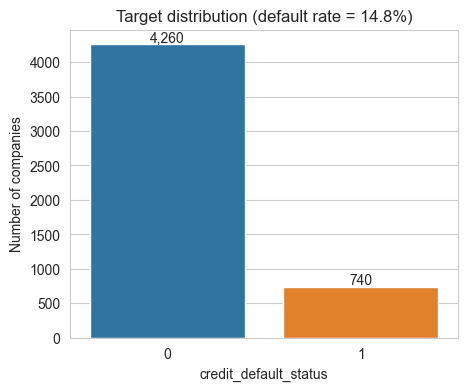

In [5]:
target_counts = df["credit_default_status"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(2)

print("Counts:")
print(target_counts)
print()
print("Percentages:")
print(target_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax,
            hue=target_counts.index.astype(str), legend=False)
ax.set_xlabel("credit_default_status")
ax.set_ylabel("Number of companies")
ax.set_title(f"Target distribution (default rate = {target_pct[1]:.1f}%)")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, f"{v:,}", ha="center")
plt.show()


## 3. Numeric feature distributions

Histograms let us eyeball whether each column's *shape* matches what the
data dictionary describes:

- `avg_monthly_inflow`, `avg_monthly_outflow` → should be right-skewed
  (most companies modest in size, a long tail of big ones), and never
  negative.
- `min_ending_balance_avg` → should pile up near ₹0 for stressed firms, and
  never go negative (a bank balance showing negative here would be a bug).
- `bounce_count_last_6m` → should be mostly 0, with a shrinking tail out to
  15.
- `cash_flow_volatility` → should sit mostly in a low-to-moderate range.
- `gst_filing_regularity_score` → should cluster high (60-100), only for
  registered firms.

We're not looking for anything precise here, just "does this look like a
real distribution, or does it look like a bug" (flat lines, impossible
negative values, a weird spike at one exact number, etc.).


In [6]:
numeric_cols_to_check = [
    "avg_monthly_inflow",
    "avg_monthly_outflow",
    "min_ending_balance_avg",
    "bounce_count_last_6m",
    "cash_flow_volatility",
    "gst_filing_regularity_score",
]

df[numeric_cols_to_check].describe()


,avg_monthly_inflow,avg_monthly_outflow,min_ending_balance_avg,bounce_count_last_6m,cash_flow_volatility,gst_filing_regularity_score
count,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4178.000000
mean,5.832845e+05,5.420516e+05,6.479999e+04,0.993400,0.307914,81.387745
std,4.724004e+05,4.366610e+05,8.050000e+04,1.583369,0.156877,10.668215
min,5.000000e+04,4.069596e+04,0.000000e+00,0.000000,0.050000,43.000000
25%,2.856913e+05,2.670290e+05,1.847797e+04,0.000000,0.191000,74.300000
50%,4.581921e+05,4.271765e+05,4.233832e+04,0.000000,0.301000,81.600000
75%,7.215180e+05,6.711856e+05,8.401664e+04,1.000000,0.414000,89.100000
max,6.890514e+06,6.040977e+06,1.452404e+06,10.000000,0.938000,100.000000


In [7]:
# Quick check for impossible negative values in columns that should never be negative.
for col in numeric_cols_to_check:
    n_negative = (df[col] < 0).sum()
    print(f"{col}: {n_negative} negative values")


avg_monthly_inflow: 0 negative values
avg_monthly_outflow: 0 negative values
min_ending_balance_avg: 0 negative values
bounce_count_last_6m: 0 negative values
cash_flow_volatility: 0 negative values
gst_filing_regularity_score: 0 negative values


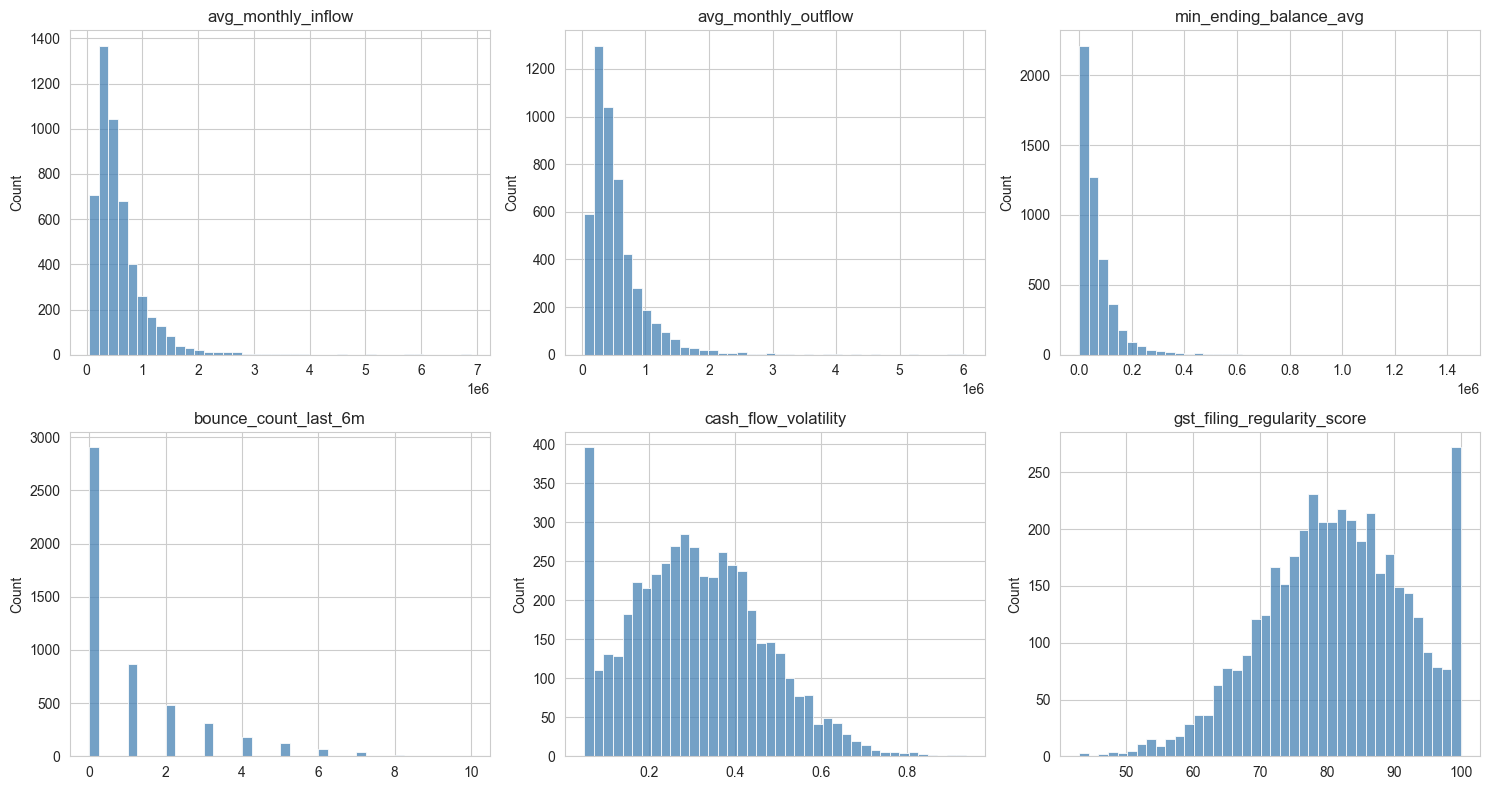

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols_to_check):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


## 4. Categorical feature distributions

Now the category columns: `business_category` and `state`. We compare the
actual percentages in the generated data against the targets written in
the data dictionary (e.g. retail ≈ 30%, trading ≈ 25%, ...). `state` has no
fixed target percentages (it's just "roughly weighted by MSME share"), so
we only chart it for a visual sanity check.


In [9]:
category_counts = df["business_category"].value_counts()
category_pct = (category_counts / len(df) * 100).round(1)

target_category_pct = {
    "retail": 30, "trading": 25, "services": 20, "manufacturing": 15, "food": 10,
}

comparison = pd.DataFrame({
    "actual_pct": category_pct,
    "target_pct": pd.Series(target_category_pct),
}).sort_values("target_pct", ascending=False)
comparison


,actual_pct,target_pct
retail,29.7,30
trading,24.2,25
services,20.4,20
manufacturing,15.0,15
food,10.7,10


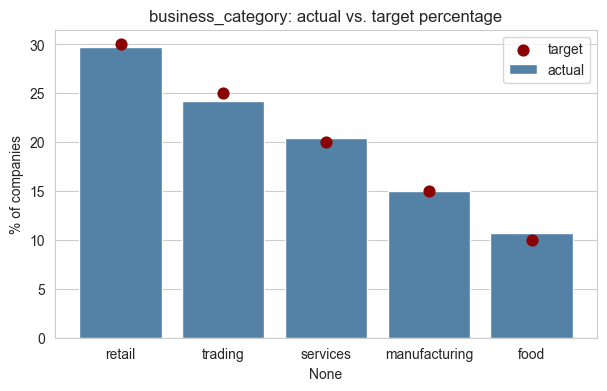

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
order = comparison.index
sns.barplot(x=order, y=comparison["actual_pct"], ax=ax, color="steelblue", label="actual")
ax.scatter(order, comparison["target_pct"], color="darkred", zorder=5, label="target", s=60)
ax.set_ylabel("% of companies")
ax.set_title("business_category: actual vs. target percentage")
ax.legend()
plt.show()


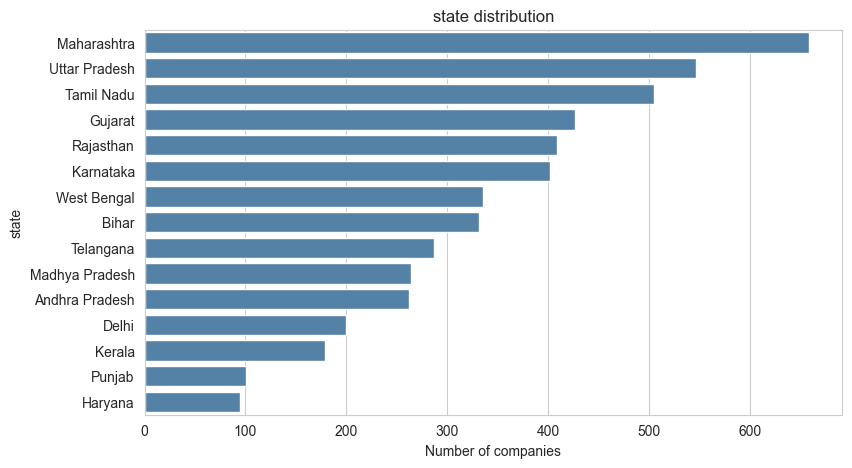

In [11]:
state_counts = df["state"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=state_counts.values, y=state_counts.index, ax=ax, color="steelblue")
ax.set_xlabel("Number of companies")
ax.set_title("state distribution")
plt.show()


## 5. Relationship sanity checks

The data dictionary doesn't just describe single columns — it describes
**rules that connect columns together** (see "How the columns relate to
each other"). This section checks those rules actually hold in the
generated CSV. If any of these failed, it would mean a bug in
`data/generate_data.py`, not just a cosmetic issue.

Checks:
1. `account_vintage_months` never exceeds `age_of_business_years * 12`.
2. GST registration is much more common once annual bank inflow passes
   ₹40 lakh.
3. For registered firms, `annual_turnover_gst` is roughly 0.7–1.1× annual
   bank inflow.
4. `bounce_count_last_6m` is higher, on average, when outflow exceeds
   inflow.
5. `upi_transaction_volume_ratio` differs meaningfully across
   `business_category`.


In [12]:
# --- Check 1: account_vintage_months <= age_of_business_years * 12 -----------
max_allowed_vintage = df["age_of_business_years"] * 12
violations_1 = (df["account_vintage_months"] > max_allowed_vintage).sum()
check_1_passed = violations_1 == 0

print("CHECK 1: account_vintage_months <= age_of_business_years * 12")
print(f"  Violations found: {violations_1} out of {len(df):,} rows")
print(f"  Result: {'PASS' if check_1_passed else 'FAIL'}")


CHECK 1: account_vintage_months <= age_of_business_years * 12
  Violations found: 0 out of 5,000 rows
  Result: PASS


In [13]:
# --- Check 2: GST registration much more common above Rs 40 lakh annual inflow ---
annual_bank_inflow = df["avg_monthly_inflow"] * 12
above_threshold = annual_bank_inflow > 40_00_000
below_threshold = ~above_threshold

reg_rate_above = df.loc[above_threshold, "has_gst_registration"].mean()
reg_rate_below = df.loc[below_threshold, "has_gst_registration"].mean()
check_2_passed = reg_rate_above > reg_rate_below + 0.20  # a clearly meaningful gap

print("CHECK 2: GST registration rate above vs. below Rs 40 lakh annual inflow")
print(f"  Registration rate ABOVE Rs 40L: {reg_rate_above:.1%}  (n={above_threshold.sum():,})")
print(f"  Registration rate BELOW Rs 40L: {reg_rate_below:.1%}  (n={below_threshold.sum():,})")
print(f"  Result: {'PASS' if check_2_passed else 'FAIL'}")


CHECK 2: GST registration rate above vs. below Rs 40 lakh annual inflow
  Registration rate ABOVE Rs 40L: 96.6%  (n=3,368)
  Registration rate BELOW Rs 40L: 56.6%  (n=1,632)
  Result: PASS


In [14]:
# --- Check 3: annual_turnover_gst ~= 0.7-1.1x annual bank inflow, for registered firms ---
registered = df["has_gst_registration"] == 1
ratio = df.loc[registered, "annual_turnover_gst"] / (df.loc[registered, "avg_monthly_inflow"] * 12)

pct_in_range = ((ratio >= 0.7) & (ratio <= 1.1)).mean()
check_3_passed = pct_in_range > 0.95  # allow a small tail outside due to rounding

print("CHECK 3: annual_turnover_gst / annual bank inflow, for registered firms")
print(f"  Mean ratio: {ratio.mean():.3f}   Median ratio: {ratio.median():.3f}")
print(f"  % of registered firms with ratio in [0.7, 1.1]: {pct_in_range:.1%}")
print(f"  Result: {'PASS' if check_3_passed else 'FAIL'}")


CHECK 3: annual_turnover_gst / annual bank inflow, for registered firms
  Mean ratio: 0.900   Median ratio: 0.899
  % of registered firms with ratio in [0.7, 1.1]: 100.0%
  Result: PASS


In [15]:
# --- Check 4: bounce_count_last_6m higher on average when outflow > inflow ---
outflow_exceeds = df["avg_monthly_outflow"] > df["avg_monthly_inflow"]

bounce_when_exceeds = df.loc[outflow_exceeds, "bounce_count_last_6m"].mean()
bounce_when_not = df.loc[~outflow_exceeds, "bounce_count_last_6m"].mean()
check_4_passed = bounce_when_exceeds > bounce_when_not

print("CHECK 4: average bounce_count_last_6m, outflow > inflow vs. not")
print(f"  Avg bounces WHEN outflow > inflow:  {bounce_when_exceeds:.2f}  (n={outflow_exceeds.sum():,})")
print(f"  Avg bounces when outflow <= inflow: {bounce_when_not:.2f}  (n={(~outflow_exceeds).sum():,})")
print(f"  Result: {'PASS' if check_4_passed else 'FAIL'}")


CHECK 4: average bounce_count_last_6m, outflow > inflow vs. not
  Avg bounces WHEN outflow > inflow:  2.56  (n=1,080)
  Avg bounces when outflow <= inflow: 0.56  (n=3,920)
  Result: PASS


In [16]:
# --- Check 5: upi_transaction_volume_ratio differs meaningfully by category ---
upi_by_category = df.groupby("business_category")["upi_transaction_volume_ratio"].mean().sort_values(ascending=False)
spread = upi_by_category.max() - upi_by_category.min()
check_5_passed = spread > 0.15  # a clearly meaningful spread across categories

print("CHECK 5: average upi_transaction_volume_ratio by business_category")
print(upi_by_category.round(3))
print(f"  Spread (max - min): {spread:.3f}")
print(f"  Result: {'PASS' if check_5_passed else 'FAIL'}")


CHECK 5: average upi_transaction_volume_ratio by business_category
business_category
retail           0.653
food             0.649
services         0.475
trading          0.304
manufacturing    0.157
Name: upi_transaction_volume_ratio, dtype: float64
  Spread (max - min): 0.496
  Result: PASS


In [17]:
print("=" * 60)
print("SECTION 5 SUMMARY")
print("=" * 60)
print(f"Check 1 (vintage <= age*12):               {'PASS' if check_1_passed else 'FAIL'}")
print(f"Check 2 (GST registration vs Rs 40L):       {'PASS' if check_2_passed else 'FAIL'}")
print(f"Check 3 (GST turnover ~ bank inflow):       {'PASS' if check_3_passed else 'FAIL'}")
print(f"Check 4 (bounces vs outflow > inflow):      {'PASS' if check_4_passed else 'FAIL'}")
print(f"Check 5 (UPI ratio varies by category):     {'PASS' if check_5_passed else 'FAIL'}")


SECTION 5 SUMMARY
Check 1 (vintage <= age*12):               PASS
Check 2 (GST registration vs Rs 40L):       PASS
Check 3 (GST turnover ~ bank inflow):       PASS
Check 4 (bounces vs outflow > inflow):      PASS
Check 5 (UPI ratio varies by category):     PASS


## 6. Feature vs. target

Does the dataset actually behave the way the data dictionary's "risk
logic" claims? For a handful of key features, we compare the average value
between companies that defaulted (`credit_default_status == 1`) and those
that didn't (`== 0`). We expect, for example, defaulted companies to have
lower cash margins, more bounces, lower GST regularity, and younger
businesses, on average.

This isn't a guarantee of model performance — it's a visual gut-check that
the labels aren't random relative to the features.


In [18]:
df["net_cash_margin"] = (df["avg_monthly_inflow"] - df["avg_monthly_outflow"]) / df["avg_monthly_inflow"]

features_vs_target = [
    "net_cash_margin",
    "min_ending_balance_avg",
    "bounce_count_last_6m",
    "cash_flow_volatility",
    "gst_filing_regularity_score",
    "age_of_business_years",
    "account_vintage_months",
    "digital_payment_adoption_score",
]

group_means = df.groupby("credit_default_status")[features_vs_target].mean().T
group_means.columns = ["default = 0 (good)", "default = 1 (bad)"]
group_means


,default = 0 (good),default = 1 (bad)
net_cash_margin,0.076234,0.024518
min_ending_balance_avg,68947.109028,40926.063000
bounce_count_last_6m,0.811737,2.039189
cash_flow_volatility,0.294566,0.384754
gst_filing_regularity_score,82.036275,77.412457
age_of_business_years,6.538075,4.768243
account_vintage_months,59.231925,42.647297
digital_payment_adoption_score,32.628991,33.498919


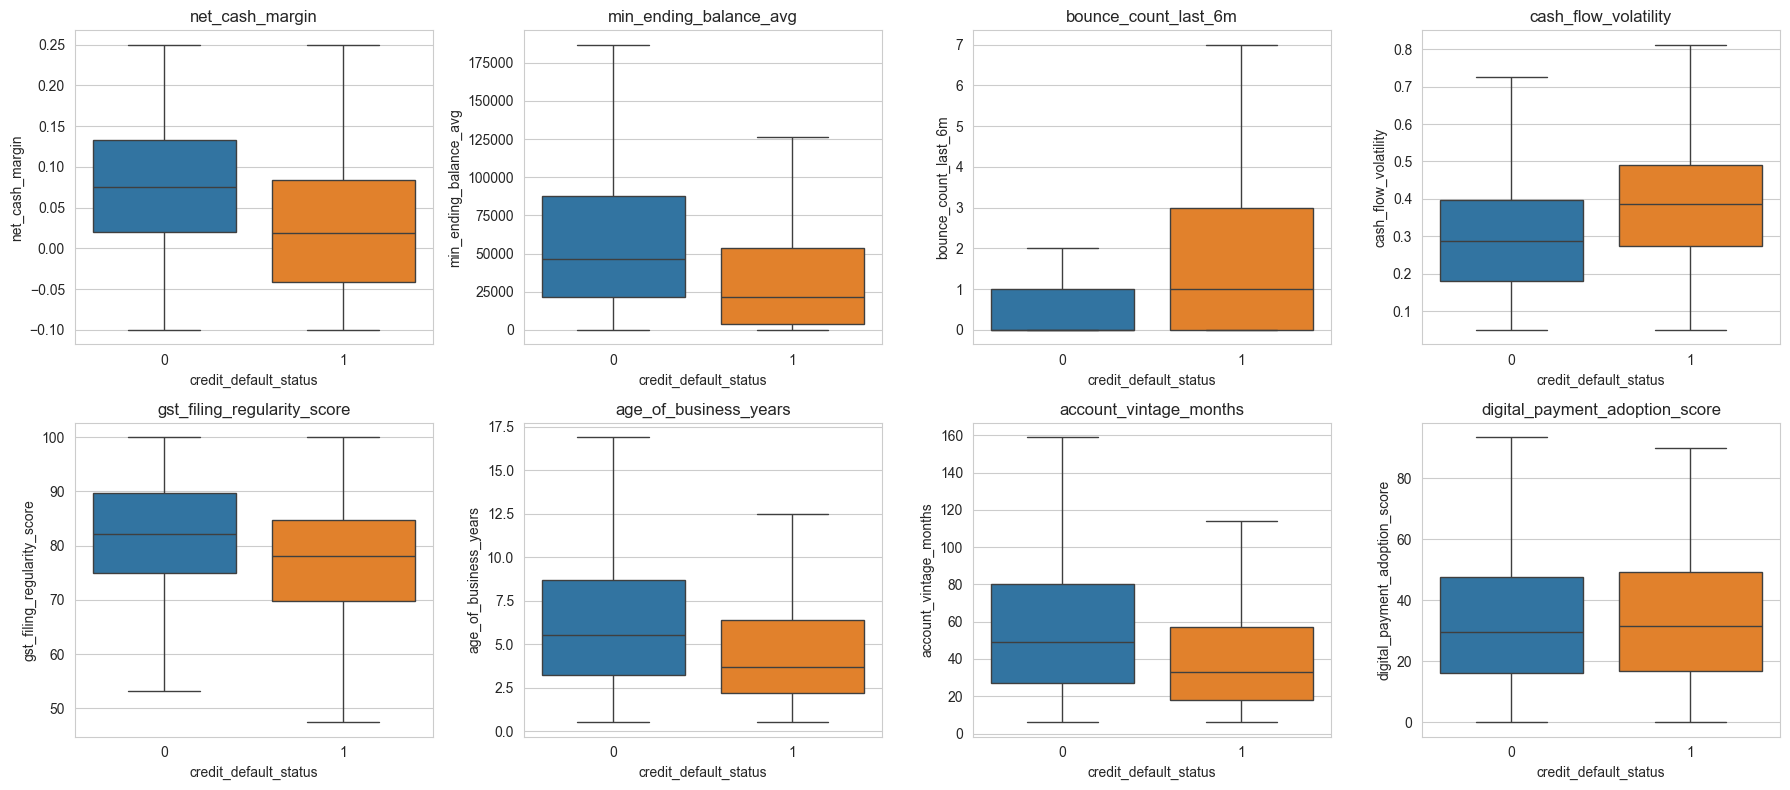

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, features_vs_target):
    sns.boxplot(data=df, x="credit_default_status", y=col, ax=ax,
                hue="credit_default_status", legend=False, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("credit_default_status")

plt.tight_layout()
plt.show()


## 7. Correlation heatmap

Finally, a correlation heatmap of the numeric columns. We're checking for
two things:

- **Expected correlations** showing up where the data dictionary says they
  should (e.g. `avg_monthly_inflow` and `annual_turnover_gst` should be
  strongly correlated, since one is built from the other).
- **Unexpected near-perfect correlations** (close to +1 or -1) between
  columns that *shouldn't* be almost identical — that would mean two
  columns are redundant and one might need to be dropped later, or that
  there's a bug.


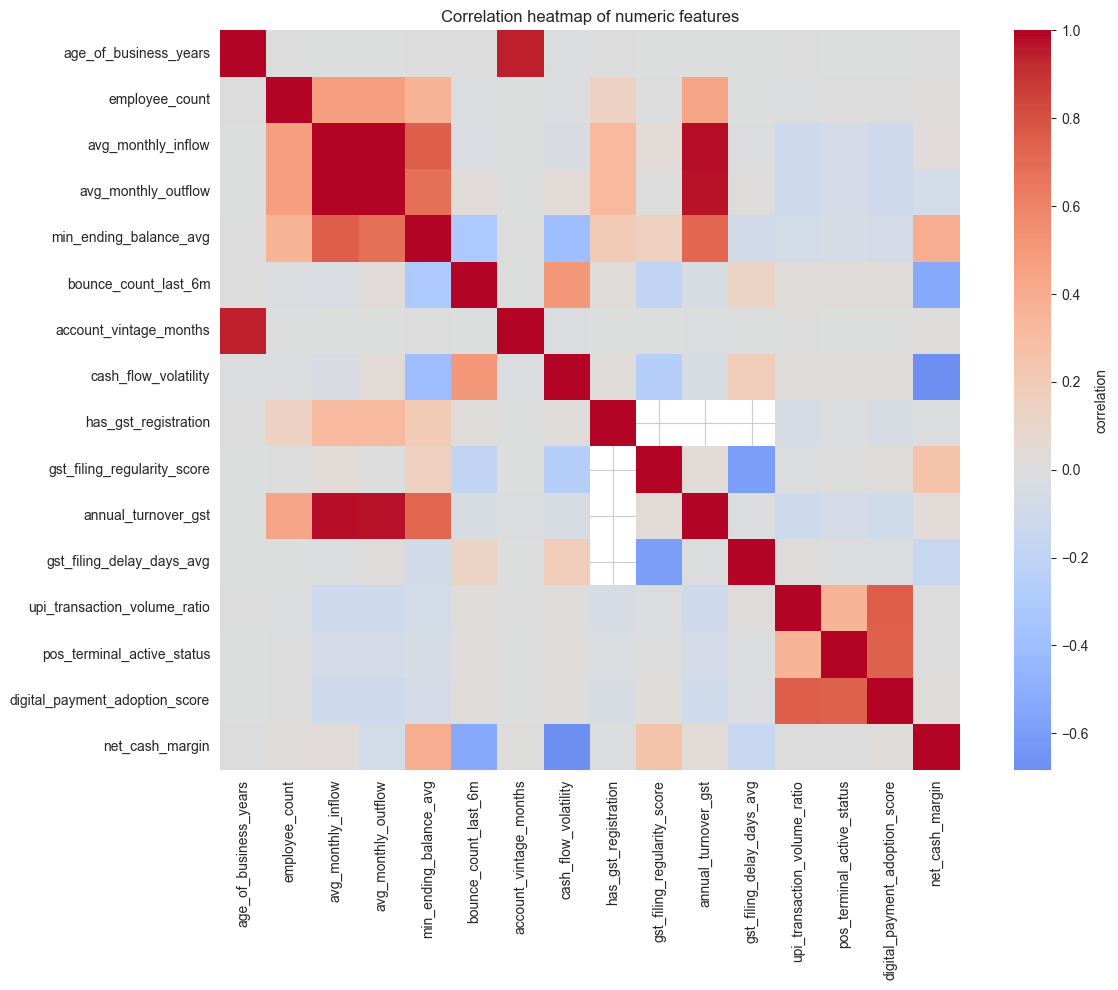

In [20]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["credit_default_status"])

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"label": "correlation"})
ax.set_title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()


In [21]:
# Flag any pair of DIFFERENT columns with |correlation| > 0.9 -- possible redundancy.
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).stack()
strong_pairs = corr_pairs[corr_pairs.abs() > 0.9].sort_values(key=abs, ascending=False)

# Each pair appears twice (A-B and B-A); keep one copy of each.
seen = set()
unique_strong_pairs = []
for (a, b), value in strong_pairs.items():
    key = frozenset([a, b])
    if key not in seen:
        seen.add(key)
        unique_strong_pairs.append((a, b, value))

print(f"Pairs with |correlation| > 0.9: {len(unique_strong_pairs)}")
for a, b, value in unique_strong_pairs:
    print(f"  {a}  <->  {b}:  {value:.3f}")


Pairs with |correlation| > 0.9: 4
  avg_monthly_inflow  <->  avg_monthly_outflow:  0.990
  avg_monthly_inflow  <->  annual_turnover_gst:  0.979
  annual_turnover_gst  <->  avg_monthly_outflow:  0.969
  age_of_business_years  <->  account_vintage_months:  0.944


## Summary — is this dataset ready for preprocessing?

**Shape & missingness:** 5,000 rows x 20 columns, as expected. Missing values
appear in exactly the 3 GST columns, and exactly for the companies with
`has_gst_registration == 0` — confirmed by direct comparison, not just a
visual check. No bug here.

**Target distribution:** 740 defaults out of 5,000 (14.80%), very close to
the 15% design target. Not so rare that training/evaluation would be hard,
not so common that it's a 50/50 coin flip either.

**Numeric distributions:** All 6 checked columns had **zero negative
values**. Histograms show the expected shapes: `avg_monthly_inflow` and
`avg_monthly_outflow` are right-skewed with a long tail of larger
companies, `bounce_count_last_6m` piles up at 0 with a shrinking tail, and
`gst_filing_regularity_score` clusters high (60-100) as designed. No signs
of generator bugs (flat lines, impossible spikes).

**Categorical distributions:** `business_category` percentages landed
close to their targets (retail/trading/services/manufacturing/food all
within ~1-2 points of 30/25/20/15/10). `state` shows a reasonable weighted
spread with no single state dominating unrealistically.

**Relationship checks (Section 5) — ALL 5 PASS** (re-run after fixing the
`account_vintage_months` rounding bug in `data/generate_data.py`):
- Check 1 (`account_vintage_months <= age_of_business_years * 12`):
  **PASS** — 0 violations out of 5,000 rows. (Previously failed with 12
  violations due to a rounding-order bug; fixed by using `floor()`
  consistently for the age-in-months cap instead of `round()`, and
  regenerating the CSV with the same seed.)
- Check 2 (GST registration rate above vs. below Rs 40L): **PASS** — 96.6%
  registered above the threshold vs. 56.6% below, a large, clear gap.
- Check 3 (GST turnover ~ 0.7-1.1x bank inflow, registered firms): **PASS**
  — 100% of registered firms fall in that range, mean ratio 0.900.
- Check 4 (bounces higher when outflow > inflow): **PASS** — 2.56 average
  bounces when outflow exceeds inflow vs. 0.56 otherwise, a large gap.
- Check 5 (UPI ratio varies by category): **PASS** — retail/food ~0.65,
  services ~0.48, trading ~0.30, manufacturing ~0.16; a wide, sensible
  spread matching the sector story.

All 5 of 5 relationship checks now pass cleanly on the corrected dataset.

**Feature vs. target (Section 6):** Box plots and group means confirm
defaulted companies look riskier on every key feature checked: lower net
cash margin, lower minimum ending balance, more bounces, higher cash flow
volatility, lower GST filing regularity, and younger business/account age,
all on average, compared to non-defaulted companies. The labels are clearly
*related* to the features, not random.

**Correlation heatmap (Section 7):** 4 pairs exceed |0.9| correlation:
`avg_monthly_inflow` <-> `avg_monthly_outflow` (0.990),
`avg_monthly_inflow` <-> `annual_turnover_gst` (0.979),
`annual_turnover_gst` <-> `avg_monthly_outflow` (0.969), and
`age_of_business_years` <-> `account_vintage_months` (0.944). All 4 are
**expected by design**, not bugs: outflow is generated as inflow times a
fairly narrow ratio, GST turnover is generated as a fraction of bank
inflow, and account vintage is capped at business age. Worth keeping in
mind for preprocessing/SHAP later — using the derived ratios
(`net_cash_margin`, `gst_to_bank_turnover_ratio`) instead of some of the
raw pairs may reduce redundancy and make SHAP attributions cleaner.

### Verdict

**Yes — this dataset is clean and realistic enough to proceed to Step 5.**
The vintage rounding bug found in the first EDA pass has been fixed and
verified at 0/5,000 violations, and all other checks pass cleanly. The
dataset is well-distributed, the default label is genuinely tied to the
risk features rather than random or trivially predictable from one column,
and no outstanding issues remain. Ready to move on to the preprocessing
pipeline.
